In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

from scipy.stats import randint, uniform

import cv2
from skimage.feature import hog, local_binary_pattern

In [3]:
train1 = pd.read_csv("data_divided/training_full.csv")
val = pd.read_csv("data_divided/validation_full.csv")
train = pd.concat([train1, val], ignore_index = True)

test = pd.read_csv("data_divided/test_full.csv")

print(f"The shape of train set: {train.shape}")
print(f"The shape of test set: {test.shape}")

The shape of train set: (16724, 12)
The shape of test set: (4181, 12)


In [5]:
train.head()

,price_numeric,Height,Width,Uniqueness,gender_guessed,gallery,painting,is_signed,age,years_selling,location,image_path
0,10673.0,64.6,62.6,Unique,unknown,gallery,other,signed,0.0,10.0,France,images_thesis\2324622_1_m.jpg
1,666.0,19.7,19.7,Unique,male,independent,other,signed,1.0,1.0,other,images_thesis\2246233_1_m.jpg
2,1275.0,45.7,35.0,Unique,male,gallery,acrylic,signed,20.0,5.0,France,images_thesis\1098924_1_m.jpg
3,972.0,18.1,15.0,Unique,male,gallery,acrylic,signed,25.0,1.0,Spain,images_thesis\2180624_1_m.jpg
4,4300.0,40.0,40.0,Unique,male,gallery,oil,not signed,3.0,3.0,United States,images_thesis\1842051_1_m.jpg


In [7]:
test.head()

,price_numeric,Height,Width,Uniqueness,gender_guessed,gallery,painting,is_signed,age,years_selling,location,image_path
0,3270.0,41.3,36.6,Unique,female,independent,acrylic,signed,2.0,3.0,France,images_thesis\2162988_1_m.jpg
1,3209.0,45.7,35.0,Unique,male,independent,other,signed,9.0,6.0,France,images_thesis\1785561_1_m.jpg
2,315.0,12.0,10.7,Unique,male,independent,other,signed,0.0,4.0,other,images_thesis\2313675_1_m.jpg
3,729.0,23.8,17.9,Unique,female,gallery,other,signed,11.0,2.0,France,images_thesis\1901280_1_m.jpg
4,1002.0,31.5,15.7,Unique,unknown,gallery,acrylic,signed,1.0,2.0,France,images_thesis\2252911_1_m.jpg


In [9]:
# remowe image_path for models on tabular data

train_tab = train.drop(columns = "image_path")
test_tab = test.drop(columns = "image_path")

In [11]:
X_train, y_train = train_tab[train_tab.drop(columns = "price_numeric").columns.to_list()], train_tab["price_numeric"]
X_test, y_test = test_tab[test_tab.drop(columns = "price_numeric").columns.to_list()], test_tab["price_numeric"]

In [13]:
X_train.head()

,Height,Width,Uniqueness,gender_guessed,gallery,painting,is_signed,age,years_selling,location
0,64.6,62.6,Unique,unknown,gallery,other,signed,0.0,10.0,France
1,19.7,19.7,Unique,male,independent,other,signed,1.0,1.0,other
2,45.7,35.0,Unique,male,gallery,acrylic,signed,20.0,5.0,France
3,18.1,15.0,Unique,male,gallery,acrylic,signed,25.0,1.0,Spain
4,40.0,40.0,Unique,male,gallery,oil,not signed,3.0,3.0,United States


In [15]:
X_test.head()

,Height,Width,Uniqueness,gender_guessed,gallery,painting,is_signed,age,years_selling,location
0,41.3,36.6,Unique,female,independent,acrylic,signed,2.0,3.0,France
1,45.7,35.0,Unique,male,independent,other,signed,9.0,6.0,France
2,12.0,10.7,Unique,male,independent,other,signed,0.0,4.0,other
3,23.8,17.9,Unique,female,gallery,other,signed,11.0,2.0,France
4,31.5,15.7,Unique,unknown,gallery,acrylic,signed,1.0,2.0,France


In [9]:

# detect column types
categorical_cols = X_train.select_dtypes(include=["object"]).columns
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns

# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# pipeline
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

# parameter distributions for randomized search
param_distributions = {
    "model__max_depth": [None, 3, 5, 7, 10, 15],
    "model__min_samples_split": randint(2, 30),
    "model__min_samples_leaf": randint(1, 20),
    "model__max_leaf_nodes": [None, 10, 20, 50, 100],
    "model__ccp_alpha": uniform(0.0, 0.05)
}

# 5-fold CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# randomized search
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    refit=True
)

# run tuning
random_search.fit(X_train, y_train)

# store best parameters
best_params = random_search.best_params_

# best trained pipeline (already refit on full training data)
best_model = random_search.best_estimator_

print("Best parameters:", best_params)
print("Best CV MAE:", -random_search.best_score_)

C:\Users\yana1\AppData\Local\Temp\ipykernel_10948\2172734889.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object"]).columns


Best parameters: {'model__ccp_alpha': np.float64(0.027335513967163983), 'model__max_depth': 15, 'model__max_leaf_nodes': 100, 'model__min_samples_leaf': 18, 'model__min_samples_split': 27}
Best CV MAE: 2255.1815703231186


In [10]:
y_pred_test = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)


In [11]:
def give_metrics(train_true, train_pred, test_true, test_pred):
    
    # train metrics
    mae_train = mean_absolute_error(train_true, train_pred)
    mse_train = mean_squared_error(train_true, train_pred)
    rmse_train = np.sqrt(mse_train)
    train_mean_y = np.mean(train_true)
    rmse_ratio_train = rmse_train / train_mean_y
    mae_ratio_train = mae_train / train_mean_y
    
    print("Metrics for the train")
    print("MAE:", mae_train)
    print("MSE:", mse_train)
    print("RMSE:", rmse_train)
    print("Normalized:", rmse_ratio_train)
    print("Normalized MAE:", mae_ratio_train)

    # test metrics
    mae_test = mean_absolute_error(test_true, test_pred)
    mse_test = mean_squared_error(test_true, test_pred)
    rmse_test = np.sqrt(mse_test)
    test_mean_y = np.mean(test_true)
    rmse_ratio_test = rmse_test / test_mean_y
    mae_ratio_test = mae_test / test_mean_y
    
    print("\nMetrics for the test")
    print("MAE:", mae_test)
    print("MSE:", mse_test)
    print("RMSE:", rmse_test)
    print("Normalized RMSE:", rmse_ratio_test)
    print("Normalized MAE:", mae_ratio_test)

In [12]:
give_metrics(y_train, y_pred_train, y_test, y_pred_test)


Metrics for the train
MAE: 2153.9048659362475
MSE: 125045640.6117921
RMSE: 11182.380811427955
Normalized: 3.5205435709412263
Normalized MAE: 0.6781128326842024

Metrics for the test
MAE: 2333.37291710969
MSE: 153307419.33207706
RMSE: 12381.737330927233
Normalized RMSE: 3.7090318144504644
Normalized MAE: 0.6989773852591341


In [13]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred_test)

0.07368333141025585

In [14]:


# pipeline for Random Forest
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# parameter distributions for randomized search
rf_param_distributions = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": randint(2, 30),
    "model__min_samples_leaf": randint(1, 20),
    "model__max_features": ["sqrt", "log2", None]
}

# 5-fold CV
rf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# randomized search
rf_random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=50,
    cv=rf_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    refit=True
)

# run tuning
rf_random_search.fit(X_train, y_train)

# store best parameters
rf_best_params = rf_random_search.best_params_

# best trained pipeline (already refit on full training data)
rf_best_model = rf_random_search.best_estimator_

print("RF Best parameters:", rf_best_params)
print("RF Best CV MAE:", -rf_random_search.best_score_)

RF Best parameters: {'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__min_samples_split': 6, 'model__n_estimators': 406}
RF Best CV MAE: 1947.307674283627


In [15]:
y_test_rf = rf_best_model.predict(X_test)
y_train_rf = rf_best_model.predict(X_train)

In [16]:
give_metrics(y_train, y_train_rf, y_test, y_test_rf)

Metrics for the train
MAE: 1637.2670717245037
MSE: 77394656.19449523
RMSE: 8797.423270168103
Normalized: 2.7696885356459315
Normalized MAE: 0.5154600044905299

Metrics for the test
MAE: 1984.9290315295827
MSE: 130156372.65922688
RMSE: 11408.609584836659
Normalized RMSE: 3.417524922218232
Normalized MAE: 0.5945987005377895


In [17]:
from xgboost import XGBRegressor

# pipeline for XGBoost
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    ))
])

# parameter distributions
xgb_param_distributions = {
    "model__n_estimators": randint(100, 600),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": uniform(0.01, 0.3),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__min_child_weight": randint(1, 10),
    "model__gamma": uniform(0, 5)
}

# 5-fold CV
xgb_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# randomized search
xgb_random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_distributions,
    n_iter=50,
    cv=xgb_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    refit=True
)

# run tuning
xgb_random_search.fit(X_train, y_train)

# store best parameters
xgb_best_params = xgb_random_search.best_params_

# best trained pipeline (already refit on full training data)
xgb_best_model = xgb_random_search.best_estimator_

print("XGB Best parameters:", xgb_best_params)
print("XGB Best CV MAE:", -xgb_random_search.best_score_)

XGB Best parameters: {'model__colsample_bytree': np.float64(0.7123738038749523), 'model__gamma': np.float64(2.7134804157912424), 'model__learning_rate': np.float64(0.052277267492428794), 'model__max_depth': 9, 'model__min_child_weight': 1, 'model__n_estimators': 444, 'model__subsample': np.float64(0.9947547746402069)}
XGB Best CV MAE: 2016.9699220853968


In [18]:
train_xg = xgb_best_model.predict(X_train)
test_xg = xgb_best_model.predict(X_test)

In [19]:
give_metrics(y_train, train_xg, y_test, test_xg)

Metrics for the train
MAE: 678.8010701573414
MSE: 2941828.952776755
RMSE: 1715.1760704886117
Normalized: 0.5399880570888766
Normalized MAE: 0.21370661434175298

Metrics for the test
MAE: 2044.1784378746086
MSE: 111404234.35034947
RMSE: 10554.82043193296
Normalized RMSE: 3.1617666997398213
Normalized MAE: 0.6123472544965373


In [20]:
import shap
import numpy as np
import pandas as pd

import shap
import numpy as np
import pandas as pd

def compute_shap_from_best_model(
    best_model,
    X_train,
    X_test,
    background_size=200,
    random_state=None,
):
    # --- extract pipeline parts ---
    preprocessor = best_model.named_steps["preprocessing"]
    model = best_model.named_steps["model"]

    # --- transform data ---
    X_train_trans = preprocessor.transform(X_train)
    X_test_trans = preprocessor.transform(X_test)

    # --- feature names ---
    feature_names = preprocessor.get_feature_names_out()

    # --- convert to DataFrame ---
    X_test_df = pd.DataFrame(X_test_trans, columns=feature_names)

    # --- reproducible RNG ---
    rng = np.random.default_rng(random_state)

    # --- background sample ---
    n_background = min(background_size, X_train_trans.shape[0])
    idx = rng.choice(X_train_trans.shape[0], size=n_background, replace=False)

    X_background = pd.DataFrame(X_train_trans[idx], columns=feature_names)

    # --- SHAP ---
    explainer = shap.Explainer(model, X_background)
    shap_values = explainer(X_test_df, check_additivity=False)

    # --- mean |SHAP| ---
    importance = np.abs(shap_values.values).mean(axis=0)

    return importance, feature_names


# --- compute for all 3 ---
imp_dt, features = compute_shap_from_best_model(best_model, X_train, X_test, random_state = 42)
imp_rf, _        = compute_shap_from_best_model(rf_best_model, X_train, X_test, random_state = 42)
imp_xgb, _       = compute_shap_from_best_model(xgb_best_model, X_train, X_test, random_state = 42)


# --- combine ---
df_imp = pd.DataFrame({
    "feature": features,
    "Decision Tree": imp_dt,
    "Random Forest": imp_rf,
    "XGBoost": imp_xgb
})

# --- sort by overall importance ---
df_imp["mean_all"] = df_imp[["Decision Tree", "Random Forest", "XGBoost"]].mean(axis=1)
df_imp = df_imp.sort_values("mean_all", ascending=False).drop(columns="mean_all")

df_imp.head()

100%|===================| 4172/4181 [02:11<00:00]        

,feature,Decision Tree,Random Forest,XGBoost
17,num__Height,1045.090815,871.475013,1220.905979
18,num__Width,928.685865,875.659991,1128.010605
19,num__age,911.097218,651.155685,1024.085468
20,num__years_selling,286.240453,243.116062,708.543468
15,cat__location_United States,38.213374,96.350134,279.308096


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# font size variables
title_fs = 18
label_fs = 16
tick_fs = 12

# optional: cleaner labels
df_plot = df_imp.copy()
df_plot["feature_clean"] = (
    df_plot["feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)

# top features separately for each model
top_n = 15
dt_top = df_plot.nlargest(top_n, "Decision Tree").sort_values("Decision Tree", ascending=True)
rf_top = df_plot.nlargest(top_n, "Random Forest").sort_values("Random Forest", ascending=True)
xgb_top = df_plot.nlargest(top_n, "XGBoost").sort_values("XGBoost", ascending=True)

# common x-axis limit across all three top-15 subsets
x_max = max(
    dt_top["Decision Tree"].max(),
    rf_top["Random Forest"].max(),
    xgb_top["XGBoost"].max()
)
x_limit = x_max * 1.05

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Decision Tree
axes[0].barh(dt_top["feature_clean"], dt_top["Decision Tree"])
axes[0].set_title("Decision Tree", fontname="Times New Roman", fontsize=title_fs)
axes[0].set_xlabel("mean(|SHAP value|)", fontname="Times New Roman", fontsize=label_fs)
axes[0].set_ylabel("Feature", fontname="Times New Roman", fontsize=label_fs)
axes[0].set_xlim(0, x_limit)
axes[0].tick_params(axis='both', labelsize=tick_fs)

# Random Forest
axes[1].barh(rf_top["feature_clean"], rf_top["Random Forest"])
axes[1].set_title("Random Forest", fontname="Times New Roman", fontsize=title_fs)
axes[1].set_xlabel("mean(|SHAP value|)", fontname="Times New Roman", fontsize=label_fs)
axes[1].set_xlim(0, x_limit)
axes[1].tick_params(axis='both', labelsize=tick_fs)

# XGBoost
axes[2].barh(xgb_top["feature_clean"], xgb_top["XGBoost"])
axes[2].set_title("XGBoost", fontname="Times New Roman", fontsize=title_fs)
axes[2].set_xlabel("mean(|SHAP value|)", fontname="Times New Roman", fontsize=label_fs)
axes[2].set_xlim(0, x_limit)
axes[2].tick_params(axis='both', labelsize=tick_fs)

plt.subplots_adjust(wspace=0.5)

plt.savefig("shap_full.png", dpi=1000)
plt.show()

NameError: name 'df_imp' is not defined

In [17]:
# define the function to load and resize images

def load_and_resize(path, size=128):     # image size reccomended for handcrafted images
    img = cv2.imread(path)
    
    if img is None:
        raise ValueError(f"Image not found: {path}")
    
    img = cv2.resize(img, (size, size))
    
    return img

In [19]:
# load images, transform to np array, define array of prices

X_train_images = np.array([
    load_and_resize(p, 128)
    for p in train["image_path"]
])

X_test_images = np.array([
    load_and_resize(p, 128)
    for p in test["image_path"]
])


In [21]:
print(X_train_images.shape)
print(X_test_images.shape)
print(y_train.shape)
print(y_test.shape)

(16724, 128, 128, 3)
(4181, 128, 128, 3)
(16724,)
(4181,)


In [23]:
print(X_train_images.dtype)
print(X_test_images.dtype)

uint8
uint8


In [25]:


def extract_image_features(images):
    
    feature_list = []
    feature_names = None

    for image in images:

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        hog_feat = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            block_norm="L2-Hys",
            feature_vector=True
        )

        lbp = local_binary_pattern(gray, 8, 1, method="uniform")
        lbp_bins = 10

        lbp_hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, lbp_bins+1),
            range=(0, lbp_bins)
        )

        lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-8)

        rgb_hist = []
        for ch in range(3):
            hist = cv2.calcHist([image],[ch],None,[32],[0,256])
            hist = cv2.normalize(hist,hist).flatten()
            rgb_hist.extend(hist)

        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

        hsv_hist = []
        ranges = [[0,180],[0,256],[0,256]]

        for ch in range(3):
            hist = cv2.calcHist([hsv],[ch],None,[32],ranges[ch])
            hist = cv2.normalize(hist,hist).flatten()
            hsv_hist.extend(hist)

        features = np.concatenate([
            hog_feat,
            lbp_hist,
            rgb_hist,
            hsv_hist
        ])

        feature_list.append(features)

        if feature_names is None:

            hog_names = [f"hog_{i}" for i in range(len(hog_feat))]
            lbp_names = [f"lbp_{i}" for i in range(len(lbp_hist))]
            rgb_names = [f"rgb_{i}" for i in range(len(rgb_hist))]
            hsv_names = [f"hsv_{i}" for i in range(len(hsv_hist))]

            feature_names = hog_names + lbp_names + rgb_names + hsv_names

    return pd.DataFrame(feature_list, columns=feature_names)

In [27]:
X_train_features = extract_image_features(X_train_images)
X_test_features = extract_image_features(X_test_images)

print(X_train_features.shape)
print(X_test_features.shape)

(16724, 8302)
(4181, 8302)


In [29]:
X_train_features.head()

,hog_0,hog_1,hog_2,hog_3,hog_4,hog_5,hog_6,hog_7,hog_8,hog_9,...,hsv_86,hsv_87,hsv_88,hsv_89,hsv_90,hsv_91,hsv_92,hsv_93,hsv_94,hsv_95
0,0.084828,0.018539,0.097338,0.080997,0.150450,0.008406,0.035519,0.004548,0.154063,0.142560,...,0.094054,0.112603,0.161485,0.185926,0.206439,0.250520,0.316424,0.333664,0.317733,0.660999
1,0.225932,0.102267,0.050903,0.123710,0.197363,0.231892,0.050040,0.092365,0.062263,0.231892,...,0.172328,0.134941,0.094050,0.064258,0.054327,0.044688,0.037386,0.038263,0.043812,0.047317
2,0.323961,0.269812,0.169521,0.067966,0.321900,0.155298,0.003641,0.111980,0.302804,0.077949,...,0.511577,0.046297,0.003370,0.001419,0.001064,0.000355,0.000177,0.003902,0.011885,0.033880
3,0.216940,0.017126,0.117515,0.004242,0.473422,0.010417,0.000000,0.015185,0.185578,0.016305,...,0.409924,0.439155,0.330517,0.234768,0.093447,0.154671,0.043961,0.019794,0.004373,0.002532
4,0.000000,0.000000,0.000000,0.001674,0.000000,0.000000,0.000000,0.000000,0.000000,0.004491,...,0.150527,0.154787,0.111982,0.064917,0.036313,0.012578,0.000406,0.000000,0.000000,0.000000


In [31]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(
    X_train_features,
    y_train,
    random_state=42
)

mi = pd.Series(mi, index=X_train_features.columns)
mi = mi.sort_values(ascending=False)

In [33]:
# 2. Choose how many features to keep
top_n = 100

selected_features = mi.index[:top_n]

# 3. Subset both train and test using TRAIN-derived feature names
X_train_selected = X_train_features.loc[:, selected_features]
X_test_selected = X_test_features.loc[:, selected_features]

In [35]:
X_train_selected.to_csv("X_train_im_full.csv")
X_test_selected.to_csv("X_test_im_full.csv")

In [41]:
X_test_selected.to_csv("features_im_full.csv")

In [31]:


model = DecisionTreeRegressor(random_state=42)

param_distributions = {
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": randint(2, 30),
    "min_samples_leaf": randint(1, 20),
    "max_leaf_nodes": [None, 10, 20, 50, 100],
    "ccp_alpha": uniform(0.0, 0.05)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

random_search_dt_im = RandomizedSearchCV(
    model,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    refit=True
)

random_search_dt_im.fit(X_train_selected, y_train)

best_model_dt_im = random_search_dt_im.best_estimator_

print("Best parameters:", random_search.best_params_)
print("Best CV MAE:", -random_search.best_score_)

Best parameters: {'model__ccp_alpha': np.float64(0.027335513967163983), 'model__max_depth': 15, 'model__max_leaf_nodes': 100, 'model__min_samples_leaf': 18, 'model__min_samples_split': 27}
Best CV MAE: 2255.1815703231186


In [32]:
y_pred_test_dtim = best_model_dt_im.predict(X_test_selected)
y_pred_train_dtim = best_model_dt_im.predict(X_train_selected)

In [33]:
give_metrics(y_train, y_pred_train_dtim, y_test, y_pred_test_dtim)

Metrics for the train
MAE: 2624.247577806074
MSE: 91396682.05481121
RMSE: 9560.161193976344
Normalized: 3.009820949239997
Normalized MAE: 0.8261906023770529

Metrics for the test
MAE: 3131.783035435216
MSE: 286214762.22190976
RMSE: 16917.88291193404
Normalized RMSE: 5.06786441001104
Normalized MAE: 0.9381464493977907


In [34]:


# define the model
rf_model = RandomForestRegressor(random_state=42)

# parameter distributions for randomized search
rf_param_distributions = {
    "n_estimators": randint(100, 500),
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": randint(2, 30),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", None]
}

# 5-fold CV
rf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# randomized search
rf_random_search_im = RandomizedSearchCV(
    rf_model,
    param_distributions=rf_param_distributions,
    n_iter=50,
    cv=rf_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    refit=True
)

# run tuning
rf_random_search_im.fit(X_train_selected, y_train)

# store best parameters
rf_best_params_im = rf_random_search_im.best_params_

# best trained model (already refit on full training data)
rf_best_model_im = rf_random_search_im.best_estimator_

print("RF Best parameters:", rf_best_params)
print("RF Best CV MAE:", -rf_random_search.best_score_)

RF Best parameters: {'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__min_samples_split': 6, 'model__n_estimators': 406}
RF Best CV MAE: 1947.307674283627


In [35]:
y_pred_test_rfim = rf_best_model_im.predict(X_test_selected)
y_pred_train_rfim = rf_best_model_im.predict(X_train_selected)

give_metrics(y_train, y_pred_train_rfim, y_test, y_pred_test_rfim)

Metrics for the train
MAE: 2764.5601217896237
MSE: 140513067.38529742
RMSE: 11853.820792693696
Normalized: 3.7319326972087072
Normalized MAE: 0.8703651330940599

Metrics for the test
MAE: 2933.156490778085
MSE: 165193454.7213437
RMSE: 12852.760587568093
Normalized RMSE: 3.8501299655042134
Normalized MAE: 0.8786465461420903


In [36]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform

# define the model
xgb_model = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

# parameter distributions for randomized search
xgb_param_distributions = {
    "n_estimators": randint(100, 600),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.3),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5)
}

# 5-fold CV
xgb_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# randomized search
xgb_random_search_im = RandomizedSearchCV(
    xgb_model,
    param_distributions=xgb_param_distributions,
    n_iter=50,
    cv=xgb_cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42,
    refit=True
)

# run tuning
xgb_random_search_im.fit(X_train_selected, y_train)

# store best parameters
xgb_best_params_im = xgb_random_search_im.best_params_

# best trained model (already refit on full training data)
xgb_best_model_im = xgb_random_search_im.best_estimator_

print("XGB Best parameters:", xgb_best_params_im)
print("XGB Best CV MAE:", -xgb_random_search_im.best_score_)

XGB Best parameters: {'colsample_bytree': np.float64(0.908897907718663), 'gamma': np.float64(0.993578407670862), 'learning_rate': np.float64(0.01165663513708072), 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 180, 'subsample': np.float64(0.88453678109946)}
XGB Best CV MAE: 2885.591776336999


In [37]:
y_pred_test_xgim = xgb_best_model_im.predict(X_test_selected)
y_pred_train_xgim = xgb_best_model_im.predict(X_train_selected)

give_metrics(y_train, y_pred_train_xgim, y_test, y_pred_test_xgim)

Metrics for the train
MAE: 2646.0012798231774
MSE: 88225491.02501903
RMSE: 9392.842542330785
Normalized: 2.9571440986405846
Normalized MAE: 0.8330393099172413

Metrics for the test
MAE: 3015.5285891788594
MSE: 170588163.40288717
RMSE: 13060.940372074561
Normalized RMSE: 3.9124916053309007
Normalized MAE: 0.9033216563811344


In [38]:
import shap
import numpy as np
import pandas as pd

def compute_shap_from_plain_model(
    best_model,
    X_train,
    X_test,
    background_size=200,
    random_state=None,
):
    # --- ensure DataFrame (preserve feature names) ---
    X_train_df = X_train.copy() if isinstance(X_train, pd.DataFrame) else pd.DataFrame(X_train)
    X_test_df  = X_test.copy()  if isinstance(X_test, pd.DataFrame)  else pd.DataFrame(X_test)

    # --- reproducible random generator ---
    rng = np.random.default_rng(random_state)

    # --- background sample ---
    n_background = min(background_size, X_train_df.shape[0])
    idx = rng.choice(X_train_df.shape[0], size=n_background, replace=False)

    X_background = X_train_df.iloc[idx].copy()

    # --- SHAP ---
    explainer = shap.Explainer(best_model, X_background)
    shap_values = explainer(X_test_df, check_additivity=False)

    # --- mean absolute SHAP importance ---
    importance = np.abs(shap_values.values).mean(axis=0)

    return importance, X_test_df.columns


# compute for all 3
imp_dt_im, features_im = compute_shap_from_plain_model(
    best_model_dt_im, X_train_selected, X_test_selected, random_state = 42
)

imp_rf_im, _ = compute_shap_from_plain_model(
    rf_best_model_im, X_train_selected, X_test_selected, random_state = 42
)

imp_xgb_im, _ = compute_shap_from_plain_model(
    xgb_best_model_im, X_train_selected, X_test_selected, random_state = 42
)

# combine
df_imp_im = pd.DataFrame({
    "feature": features_im,
    "Decision Tree": imp_dt_im,
    "Random Forest": imp_rf_im,
    "XGBoost": imp_xgb_im
})

df_imp_im.head()

,feature,Decision Tree,Random Forest,XGBoost
0,hog_7873,0.0,7.607683,3.162413
1,rgb_61,0.0,13.147452,4.874233
2,hog_1636,0.0,8.037398,6.164231
3,hog_2724,0.0,11.325234,10.268485
4,hog_441,0.0,12.338819,5.407200


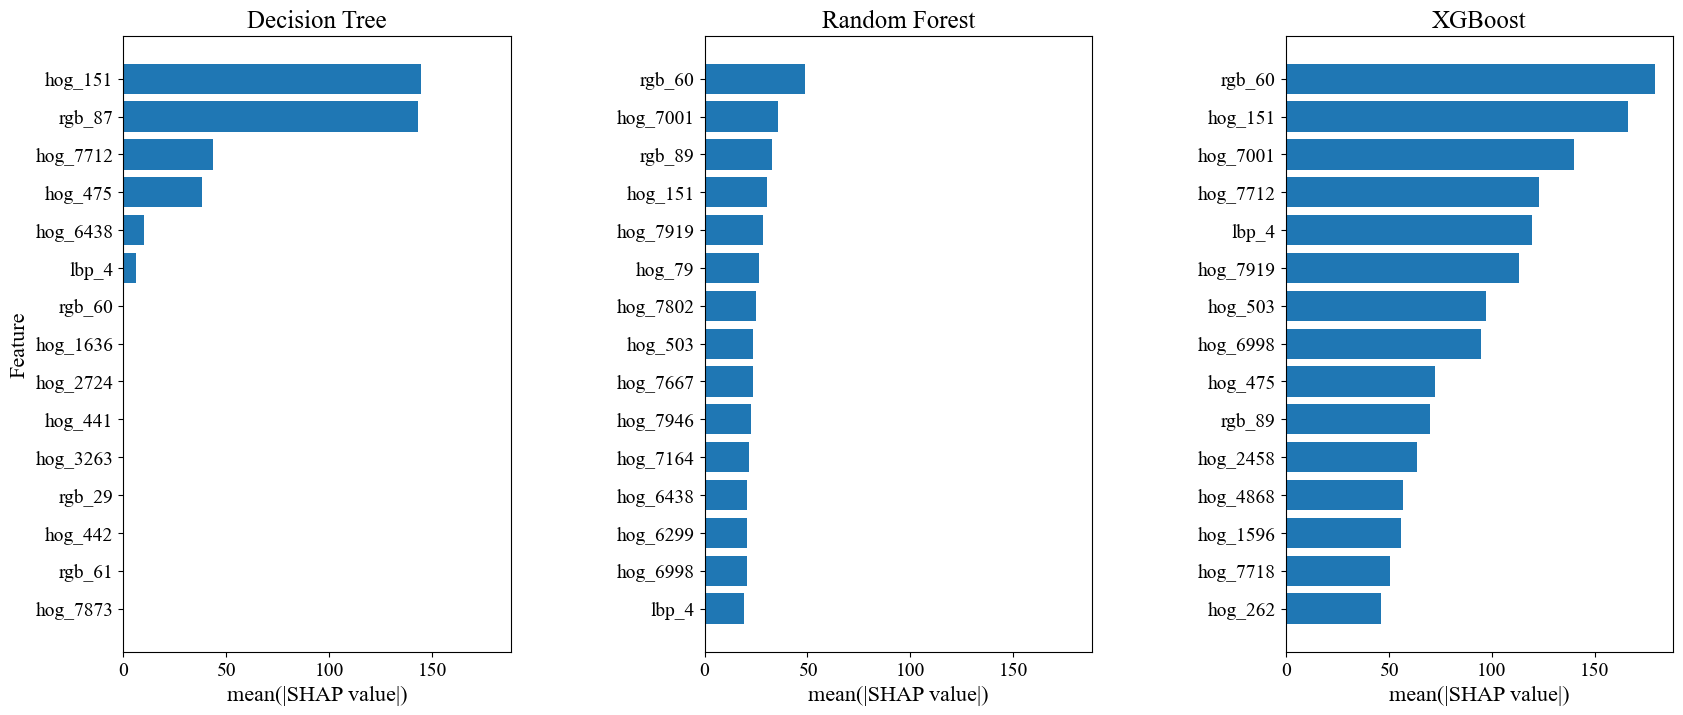

In [101]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

# font size variables
title_fs = 18
label_fs = 16
tick_fs = 14

df_plot = df_imp_im.copy()

top_n = 15

# --- top features per model ---
dt_top = df_plot.nlargest(top_n, "Decision Tree").sort_values("Decision Tree", ascending=True)
rf_top = df_plot.nlargest(top_n, "Random Forest").sort_values("Random Forest", ascending=True)
xgb_top = df_plot.nlargest(top_n, "XGBoost").sort_values("XGBoost", ascending=True)

# --- shared x-axis limit ---
x_max = max(
    dt_top["Decision Tree"].max(),
    rf_top["Random Forest"].max(),
    xgb_top["XGBoost"].max()
)
x_limit = x_max * 1.05

# --- plot ---
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Decision Tree
axes[0].barh(dt_top["feature"], dt_top["Decision Tree"])
axes[0].set_title("Decision Tree", fontsize=title_fs)
axes[0].set_xlabel("mean(|SHAP value|)", fontsize=label_fs)
axes[0].set_ylabel("Feature", fontsize=label_fs)
axes[0].set_xlim(0, x_limit)
axes[0].tick_params(axis='both', labelsize=tick_fs)

# Random Forest
axes[1].barh(rf_top["feature"], rf_top["Random Forest"])
axes[1].set_title("Random Forest", fontsize=title_fs)
axes[1].set_xlabel("mean(|SHAP value|)", fontsize=label_fs)
axes[1].set_xlim(0, x_limit)
axes[1].tick_params(axis='both', labelsize=tick_fs)

# XGBoost
axes[2].barh(xgb_top["feature"], xgb_top["XGBoost"])
axes[2].set_title("XGBoost", fontsize=title_fs)
axes[2].set_xlabel("mean(|SHAP value|)", fontsize=label_fs)
axes[2].set_xlim(0, x_limit)
axes[2].tick_params(axis='both', labelsize=tick_fs)

plt.subplots_adjust(wspace=0.5)

plt.savefig("shap_im_full.png", dpi=700)

plt.show()

In [40]:
import joblib

# save
joblib.dump(best_model, "best_model_dt.joblib")
joblib.dump(rf_best_model, "rf_best_model.joblib")
joblib.dump(xgb_best_model, "xgb_best_model.joblib")
joblib.dump(best_model_dt_im, "best_model_dt_im.joblib")
joblib.dump(rf_best_model_im, "best_model_rf_im.joblib")
joblib.dump(xgb_best_model_im, "best_model_xgb_im.joblib")


['best_model_xgb_im.joblib']

In [41]:
df_imp.to_csv("df_imp_full.csv")
df_imp_im.to_csv("df_imp_im_full.csv")